In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import metaCommunityMx

Text(0, 0.5, 'Abundance')

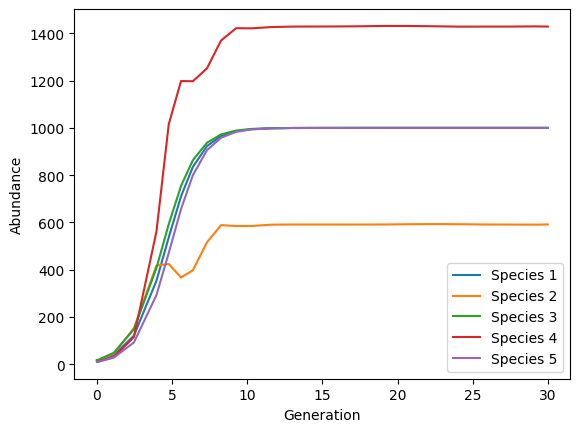

In [35]:
def one_comm_dynamics(t, N, a, b, alpha):
    dNdt = N*(b*(1 - alpha*N) + (a@N))
    return dNdt
    
nSpecies = 5
alpha = 0.001

#below would be replaced with a get or generate matrix function
a = np.random.choice([0,1], size = (nSpecies,nSpecies), p=[0.6,0.4]) * np.random.uniform(low = -.01, high = .01, size = (nSpecies,nSpecies))
a = metaCommunityMx.getRandomMatrix(pPositive=0.5, pInteract=0.1, nSpecies=nSpecies, maxInteractionStrength = 0.003, pBidirectional=0)

#random vector of birthrates with noise
b = np.ones(nSpecies)-np.random.uniform(low = 0, high = 0.1, size = (nSpecies))
tspan = [0,30]
#random initial vector of starting densities
y0 = np.random.uniform(low = 10, high = 20, size = (nSpecies))

def myFun(t, N):
    return one_comm_dynamics(t, N, a, b, alpha)

sol = solve_ivp(myFun, tspan, y0)
plt.plot(sol.t, sol.y[0], sol.t, sol.y[1], sol.t,sol.y[2], sol.t,sol.y[3],sol.t,sol.y[4])
plt.legend(["Species 1", "Species 2", "Species 3", "Species 4", "Species 5"])
plt.xlabel("Generation")
plt.ylabel("Abundance")


In [36]:

'''
Subsampling community and simulating dynamics:
samplesize (float): number of species to subsample from the entire community matrix for one simulation
numtrials (float): number of iterations to run
nSpecies (float): number of species
indexList (array): each row gives the species indices selected for a trial
summarytable (array): each row corresponds to one trial; column # is final population size of the corresponding species index

'''
def community_dynamics(t, N, b, a):
    #b is birthrate vector, a is interaction matrix
    dNdt = N*(b*(1-.05*N) + (a@N))
    return dNdt

samplesize = 5
numtrials = 500
nSpecies = 20
tspan = [0,30]
summarytable = np.zeros((numtrials,nSpecies))
indexlist = np.zeros((numtrials,samplesize))

#generate community interaction matrix (currently the old, random way)
a = np.random.choice([0,1], size = (nSpecies,nSpecies), p=[0.6,0.4]) * np.random.uniform(low = -.21, high = .01, size = (nSpecies,nSpecies))
np.fill_diagonal(a,0)

#random birthrates with noise
b = np.ones(nSpecies)-np.random.uniform(low = 0, high = .1, size = (nSpecies))

for i in range(numtrials):
    #get list of samplesize random integers from 0 to nSpecies (save list)
    spList = np.random.choice(range(0, nSpecies), size = (samplesize), replace = False)
    spList.sort()
    indexlist[i,:] = spList

    #take rows and columns of community interaction matrix that correspond to those integers for reduced interaction matrix
    reducedMx = a[np.ix_(spList, spList)]
    #also subsample birthrates 
    reducedb = b[spList]

    #run ode solver for reduced interaction matrix

    #random initial vector of starting densities
    y0 = np.random.uniform(low = 10, high = 20, size = (samplesize))

    sol = solve_ivp(community_dynamics, tspan, y0, args = (reducedb,reducedMx))

    #output: table with numtrial as rows and species populations as columns
    for x in range(samplesize):
        summarytable[(i,spList[x])] = sol.y[x,-1] 

